In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [27]:
df = pd.read_csv("thyroid_dataset.csv")

In [28]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [29]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [30]:
from sklearn.neighbors import LocalOutlierFactor

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
neighbs = LocalOutlierFactor(contamination=0.036)

labels = neighbs.fit_predict(X_scaled)

In [33]:
# Visualize
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

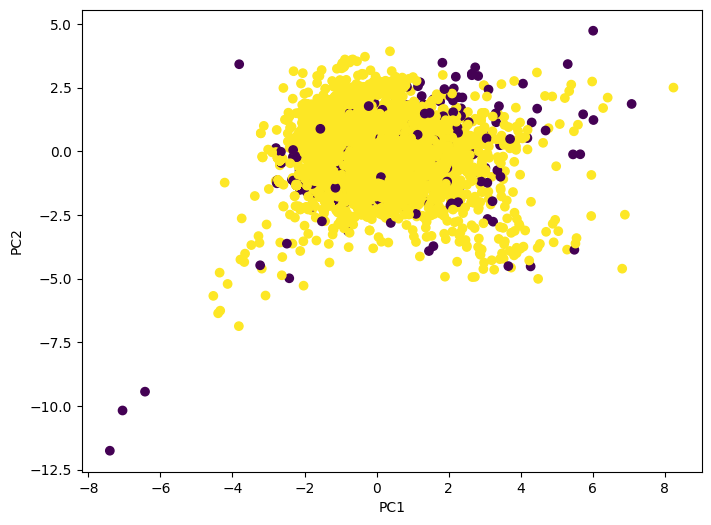

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [35]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outlier = ", n_outliers)
print("normal = ", n_normal)

outlier =  249
normal =  6667
